# Exploración de resultados: retrained-subset retention

Este notebook analiza los archivos generados por:

```bash
python -m scripts.ranking_retention_retrain ...
```

Archivos esperados:

- `tables_retrain_all_random3/ranking_retention_retrain_auc.csv`
- `tables_retrain_all_random3/ranking_retention_retrain_curves.csv`
- `tables_retrain_all_random3/ranking_retention_retrain_summary.json`

Objetivo: comparar `fulltrust_agg_selection`, `timetrust_selection`, `weights`, `group_ablation` y `random_permutation` bajo el protocolo de **reentrenar una MLP para cada subconjunto top-k**.

In [1]:
from pathlib import Path
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

pd.set_option("display.max_rows", 250)
pd.set_option("display.max_columns", 250)
pd.set_option("display.width", 200)

# Cambia esto si usaste otro out-dir.
TABLES_DIR = Path("tables_retrain_all_random3")

AUC_PATH = TABLES_DIR / "ranking_retention_retrain_auc.csv"
CURVES_PATH = TABLES_DIR / "ranking_retention_retrain_curves.csv"
SUMMARY_PATH = TABLES_DIR / "ranking_retention_retrain_summary.json"

print("AUC exists:", AUC_PATH.exists(), AUC_PATH)
print("Curves exists:", CURVES_PATH.exists(), CURVES_PATH)
print("Summary exists:", SUMMARY_PATH.exists(), SUMMARY_PATH)

AUC exists: True tables_retrain_all_random3/ranking_retention_retrain_auc.csv
Curves exists: True tables_retrain_all_random3/ranking_retention_retrain_curves.csv
Summary exists: True tables_retrain_all_random3/ranking_retention_retrain_summary.json


In [2]:
auc = pd.read_csv(AUC_PATH)
curves = pd.read_csv(CURVES_PATH)

print("auc shape:", auc.shape)
print("curves shape:", curves.shape)

if "dataset" in auc.columns:
    auc = auc[auc["dataset"].astype(str).ne("FAKE_DATASET")].reset_index(drop=True)
if "dataset" in curves.columns:
    curves = curves[curves["dataset"].astype(str).ne("FAKE_DATASET")].reset_index(drop=True)

print("After removing FAKE_DATASET:")
print("auc shape:", auc.shape)
print("curves shape:", curves.shape)

display(auc.head())
display(curves.head())
print("AUC columns:")
print(list(auc.columns))
print("Curves columns:")
print(list(curves.columns))

auc shape: (210, 32)
curves shape: (1449, 27)
After removing FAKE_DATASET:
auc shape: (168, 32)
curves shape: (1176, 27)


,dataset,window_tag,hidden_tag,group_mode,method,random_trial,n_groups,n_points,ks_evaluated,mae_full_ref,rmse_full_ref,mae_mean_ref,rmse_mean_ref,mean_y_train,ranking_file,partial_auc_lo,partial_auc_hi,retrain_retention_auc,retrain_retention_auc_20_80,retrain_retention_auc_20_80_raw,retrain_retention_at_20,retrain_retention_at_80,val_mae_auc,val_mae_auc_20_80,val_mae_auc_20_80_raw,val_mae_at_20,val_mae_at_80,val_rmse_auc,val_rmse_auc_20_80,val_rmse_auc_20_80_raw,val_rmse_at_20,val_rmse_at_80
0,FD001,W30_step1,h10,sensors,fulltrust_agg_selection,-1,15,7,"0,2,3,6,9,12,15",33.5037,45.745193,56.598259,70.934616,93.060844,mlp_baselines/FD001/W30_step1/h10/rankings/ran...,0.2,0.8,0.989492,1.128359,0.677016,0.999986,1.175884,33.746382,30.539297,18.323578,33.504032,29.441730,47.086271,43.083939,25.850364,45.927383,41.944752
1,FD001,W30_step1,h10,sensors,timetrust_selection,-1,15,7,"0,2,3,6,9,12,15",33.5037,45.745193,56.598259,70.934616,93.060844,mlp_baselines/FD001/W30_step1/h10/rankings/ran...,0.2,0.8,1.029295,1.126197,0.675718,0.999986,1.191627,32.827151,30.589235,18.353541,33.504032,29.078157,45.506412,43.040011,25.824007,45.927383,41.743156
2,FD001,W30_step1,h10,sensors,weights,-1,15,7,"0,2,3,6,9,12,15",33.5037,45.745193,56.598259,70.934616,93.060844,mlp_baselines/FD001/W30_step1/h10/rankings/ran...,0.2,0.8,0.930604,1.061504,0.636903,0.748807,1.071860,35.106375,32.083283,19.249970,39.304893,31.844122,48.561277,44.741505,26.844903,51.513813,44.887276
3,FD001,W30_step1,h10,sensors,group_ablation,-1,15,7,"0,2,3,6,9,12,15",33.5037,45.745193,56.598259,70.934616,93.060844,mlp_baselines/FD001/W30_step1/h10/rankings/ran...,0.2,0.8,0.969349,1.098061,0.658836,0.999986,1.196534,34.211564,31.239029,18.743418,33.504032,28.964827,47.136296,43.826243,26.295746,45.927383,41.575920
4,FD001,W30_step1,h10,sensors,random_permutation,0,15,7,"0,2,3,6,9,12,15",33.5037,45.745193,56.598259,70.934616,93.060844,NaN,0.2,0.8,0.990892,1.074127,0.644476,0.962977,1.151112,33.714042,31.791763,19.075058,34.358723,30.013840,45.902935,43.336083,26.001650,46.091805,42.496655


,dataset,window_tag,hidden_tag,group_mode,method,random_trial,k,n_groups,fraction_kept,n_features_kept,input_dim,train_mae,train_rmse,val_mae,val_rmse,retrain_retention,mae_full_ref,rmse_full_ref,mae_mean_ref,rmse_mean_ref,mean_y_train,ranking_file,train_seed,cache_hit,epochs,last_train_loss,last_val_loss
0,FD001,W30_step1,h10,sensors,fulltrust_agg_selection,-1,0,15,0.000000,0,0,NaN,NaN,56.598259,70.934616,0.000000,33.5037,45.745193,56.598259,70.934616,93.060844,mlp_baselines/FD001/W30_step1/h10/rankings/ran...,-1,False,NaN,NaN,NaN
1,FD001,W30_step1,h10,sensors,fulltrust_agg_selection,-1,2,15,0.133333,60,60,38.961224,50.790306,43.234230,61.723755,0.578666,33.5037,45.745193,56.598259,70.934616,93.060844,mlp_baselines/FD001/W30_step1/h10/rankings/ran...,3791017354,False,60.0,2587.544434,3809.822021
2,FD001,W30_step1,h10,sensors,fulltrust_agg_selection,-1,3,15,0.200000,90,90,24.937220,35.451073,33.504032,45.927383,0.999986,33.5037,45.745193,56.598259,70.934616,93.060844,mlp_baselines/FD001/W30_step1/h10/rankings/ran...,1517804816,False,60.0,1260.449463,2109.324463
3,FD001,W30_step1,h10,sensors,fulltrust_agg_selection,-1,6,15,0.400000,180,180,22.839649,33.241989,30.446348,42.870903,1.132384,33.5037,45.745193,56.598259,70.934616,93.060844,mlp_baselines/FD001/W30_step1/h10/rankings/ran...,1776052107,False,60.0,1110.324219,1837.914429
4,FD001,W30_step1,h10,sensors,fulltrust_agg_selection,-1,9,15,0.600000,270,270,22.472492,32.521320,29.698662,42.444847,1.164759,33.5037,45.745193,56.598259,70.934616,93.060844,mlp_baselines/FD001/W30_step1/h10/rankings/ran...,3952989811,False,60.0,1064.662354,1801.565063


AUC columns:
['dataset', 'window_tag', 'hidden_tag', 'group_mode', 'method', 'random_trial', 'n_groups', 'n_points', 'ks_evaluated', 'mae_full_ref', 'rmse_full_ref', 'mae_mean_ref', 'rmse_mean_ref', 'mean_y_train', 'ranking_file', 'partial_auc_lo', 'partial_auc_hi', 'retrain_retention_auc', 'retrain_retention_auc_20_80', 'retrain_retention_auc_20_80_raw', 'retrain_retention_at_20', 'retrain_retention_at_80', 'val_mae_auc', 'val_mae_auc_20_80', 'val_mae_auc_20_80_raw', 'val_mae_at_20', 'val_mae_at_80', 'val_rmse_auc', 'val_rmse_auc_20_80', 'val_rmse_auc_20_80_raw', 'val_rmse_at_20', 'val_rmse_at_80']
Curves columns:
['dataset', 'window_tag', 'hidden_tag', 'group_mode', 'method', 'random_trial', 'k', 'n_groups', 'fraction_kept', 'n_features_kept', 'input_dim', 'train_mae', 'train_rmse', 'val_mae', 'val_rmse', 'retrain_retention', 'mae_full_ref', 'rmse_full_ref', 'mae_mean_ref', 'rmse_mean_ref', 'mean_y_train', 'ranking_file', 'train_seed', 'cache_hit', 'epochs', 'last_train_loss', 'last_

## Resumen de ejecución

Revisa que no haya errores antes de interpretar resultados.

In [3]:
if SUMMARY_PATH.exists():
    with open(SUMMARY_PATH, "r", encoding="utf-8") as f:
        summary = json.load(f)
    print(json.dumps({
        "counts": summary.get("counts", {}),
        "config": summary.get("config", {}),
        "outputs": summary.get("outputs", {}),
    }, indent=2))
    errors = summary.get("errors", [])
    print("n_errors:", len(errors))
    if errors:
        display(pd.DataFrame(errors).head(30))
else:
    summary = {}
    print("No summary.json found.")

{
  "counts": {
    "targets_found": 15,
    "curve_rows": 1449,
    "auc_rows": 210,
    "errors": 0
  },
  "config": {
    "processed_root": "datasets/processed",
    "baselines_root": "mlp_baselines",
    "out_dir": "tables_retrain_all_random3",
    "only_dataset": null,
    "only_window_tag": null,
    "only_hidden": null,
    "only_group_mode": null,
    "n_random": 3,
    "seed": 2026,
    "fractions": [
      0.1,
      0.2,
      0.4,
      0.6,
      0.8,
      1.0
    ],
    "all_k": false,
    "epochs": 60,
    "train_batch_size": 128,
    "predict_batch_size": 1024,
    "learning_rate": 0.001,
    "keras_verbose": 0,
    "include_group_ablation": true,
    "include_random": true,
    "partial_auc_lo": 0.2,
    "partial_auc_hi": 0.8
  },
  "outputs": {
    "curves_csv": "tables_retrain_all_random3/ranking_retention_retrain_curves.csv",
    "auc_csv": "tables_retrain_all_random3/ranking_retention_retrain_auc.csv",
    "summary_json": "tables_retrain_all_random3/ranking_retent

## Nombres, orden visual y detección de métricas

En retraining, las métricas más importantes son:

- `val_mae_auc_20_80` ↓: menor es mejor.
- `val_mae_auc` ↓: menor es mejor.
- `retrain_retention_auc_20_80` ↑: mayor es mejor.
- `retrain_retention_auc` ↑: mayor es mejor.

La métrica recomendada para tabla principal suele ser `val_mae_auc_20_80`, porque retention puede superar 1 si el modelo reentrenado con un subconjunto supera al baseline full-input.

In [4]:
METHOD_LABELS = {
    "fulltrust_agg_selection": "Full TRUST agg.",
    "timetrust_selection": "Time-TRUST",
    "weights": "Weights",
    "group_ablation": "Group ablation",
    "random_permutation": "Random",
    "random_mean": "Random mean",
}

METHOD_ORDER = [
    "fulltrust_agg_selection",
    "timetrust_selection",
    "weights",
    "group_ablation",
    "random_permutation",
]

METHOD_LABEL_ORDER = [
    "Full TRUST agg.",
    "Time-TRUST",
    "Weights",
    "Group ablation",
    "Random mean",
]

GROUP_ORDER = ["sensors", "windows"]
HIDDEN_ORDER = ["h10", "h10_10", "h10_10_10"]
DATASET_ORDER = ["FD001", "FD002", "FD003", "FD004"]

def method_label(m):
    return METHOD_LABELS.get(str(m), str(m))

for df in [auc, curves]:
    if "method" in df.columns:
        df["method_label"] = df["method"].map(method_label)
    if "dataset" in df.columns:
        df["dataset"] = pd.Categorical(df["dataset"].astype(str), categories=DATASET_ORDER, ordered=True)
    if "hidden_tag" in df.columns:
        df["hidden_tag"] = pd.Categorical(df["hidden_tag"].astype(str), categories=HIDDEN_ORDER, ordered=True)
    if "group_mode" in df.columns:
        df["group_mode"] = pd.Categorical(df["group_mode"].astype(str), categories=GROUP_ORDER, ordered=True)

def first_existing(cols):
    for c in cols:
        if c in auc.columns:
            return c
    return None

METRIC_MAE_20_80 = first_existing(["val_mae_auc_20_80", "mae_auc_20_80"])
METRIC_MAE_FULL = first_existing(["val_mae_auc", "mae_auc"])
METRIC_RET_20_80 = first_existing(["retrain_retention_auc_20_80", "retention_auc_20_80"])
METRIC_RET_FULL = first_existing(["retrain_retention_auc", "retention_auc"])

print("METRIC_MAE_20_80:", METRIC_MAE_20_80)
print("METRIC_MAE_FULL:", METRIC_MAE_FULL)
print("METRIC_RET_20_80:", METRIC_RET_20_80)
print("METRIC_RET_FULL:", METRIC_RET_FULL)

id_cols = ["dataset", "window_tag", "hidden_tag", "group_mode"]
display(auc.head(15))

METRIC_MAE_20_80: val_mae_auc_20_80
METRIC_MAE_FULL: val_mae_auc
METRIC_RET_20_80: retrain_retention_auc_20_80
METRIC_RET_FULL: retrain_retention_auc


,dataset,window_tag,hidden_tag,group_mode,method,random_trial,n_groups,n_points,ks_evaluated,mae_full_ref,rmse_full_ref,mae_mean_ref,rmse_mean_ref,mean_y_train,ranking_file,partial_auc_lo,partial_auc_hi,retrain_retention_auc,retrain_retention_auc_20_80,retrain_retention_auc_20_80_raw,retrain_retention_at_20,retrain_retention_at_80,val_mae_auc,val_mae_auc_20_80,val_mae_auc_20_80_raw,val_mae_at_20,val_mae_at_80,val_rmse_auc,val_rmse_auc_20_80,val_rmse_auc_20_80_raw,val_rmse_at_20,val_rmse_at_80,method_label
0,FD001,W30_step1,h10,sensors,fulltrust_agg_selection,-1,15,7,"0,2,3,6,9,12,15",33.503700,45.745193,56.598259,70.934616,93.060844,mlp_baselines/FD001/W30_step1/h10/rankings/ran...,0.2,0.8,0.989492,1.128359,0.677016,0.999986,1.175884,33.746382,30.539297,18.323578,33.504032,29.441730,47.086271,43.083939,25.850364,45.927383,41.944752,Full TRUST agg.
1,FD001,W30_step1,h10,sensors,timetrust_selection,-1,15,7,"0,2,3,6,9,12,15",33.503700,45.745193,56.598259,70.934616,93.060844,mlp_baselines/FD001/W30_step1/h10/rankings/ran...,0.2,0.8,1.029295,1.126197,0.675718,0.999986,1.191627,32.827151,30.589235,18.353541,33.504032,29.078157,45.506412,43.040011,25.824007,45.927383,41.743156,Time-TRUST
2,FD001,W30_step1,h10,sensors,weights,-1,15,7,"0,2,3,6,9,12,15",33.503700,45.745193,56.598259,70.934616,93.060844,mlp_baselines/FD001/W30_step1/h10/rankings/ran...,0.2,0.8,0.930604,1.061504,0.636903,0.748807,1.071860,35.106375,32.083283,19.249970,39.304893,31.844122,48.561277,44.741505,26.844903,51.513813,44.887276,Weights
3,FD001,W30_step1,h10,sensors,group_ablation,-1,15,7,"0,2,3,6,9,12,15",33.503700,45.745193,56.598259,70.934616,93.060844,mlp_baselines/FD001/W30_step1/h10/rankings/ran...,0.2,0.8,0.969349,1.098061,0.658836,0.999986,1.196534,34.211564,31.239029,18.743418,33.504032,28.964827,47.136296,43.826243,26.295746,45.927383,41.575920,Group ablation
4,FD001,W30_step1,h10,sensors,random_permutation,0,15,7,"0,2,3,6,9,12,15",33.503700,45.745193,56.598259,70.934616,93.060844,NaN,0.2,0.8,0.990892,1.074127,0.644476,0.962977,1.151112,33.714042,31.791763,19.075058,34.358723,30.013840,45.902935,43.336083,26.001650,46.091805,42.496655,Random
5,FD001,W30_step1,h10,sensors,random_permutation,1,15,7,"0,2,3,6,9,12,15",33.503700,45.745193,56.598259,70.934616,93.060844,NaN,0.2,0.8,1.021899,1.106462,0.663877,0.995913,1.150007,32.997956,31.045002,18.627001,33.598091,30.039349,45.526507,43.166317,25.899790,45.274361,42.052383,Random
6,FD001,W30_step1,h10,sensors,random_permutation,2,15,7,"0,2,3,6,9,12,15",33.503700,45.745193,56.598259,70.934616,93.060844,NaN,0.2,0.8,0.967361,1.051800,0.631080,0.934641,1.120875,34.257491,32.307394,19.384436,35.013138,30.712154,47.266220,45.030890,27.018534,49.048126,43.727844,Random
7,FD001,W30_step1,h10,windows,fulltrust_agg_selection,-1,30,7,"0,3,6,12,18,24,30",33.503700,45.745193,56.598259,70.934616,93.060844,mlp_baselines/FD001/W30_step1/h10/rankings/ran...,0.2,0.8,1.042564,1.121511,0.672907,1.036042,1.094113,32.520694,30.697453,18.418472,32.671322,31.330191,45.229875,43.168046,25.900828,45.368065,43.475861,Full TRUST agg.
8,FD001,W30_step1,h10,windows,timetrust_selection,-1,30,7,"0,3,6,12,18,24,30",33.503700,45.745193,56.598259,70.934616,93.060844,mlp_baselines/FD001/W30_step1/h10/rankings/ran...,0.2,0.8,1.099982,1.175678,0.705407,1.175778,1.210610,31.194665,29.446497,17.667898,29.444193,28.639755,44.153293,42.175492,25.305295,42.536499,41.145687,Time-TRUST
9,FD001,W30_step1,h10,windows,weights,-1,30,7,"0,3,6,12,18,24,30",33.503700,45.745193,56.598259,70.934616,93.060844,mlp_baselines/FD001/W30_step1/h10/rankings/ran...,0.2,0.8,1.098194,1.198416,0.719050,1.096920,1.158538,31.235958,28.921364,17.352818,31.265373,29.842342,44.154846,41.773300,25.063980,43.391537,42.082314,Weights


## Resumen global por método

Para random hay múltiples trials. Esta tabla todavía trata cada random trial como fila independiente; más abajo se colapsa random a media por configuración.

In [5]:
agg_dict = {
    "n_rows": ("method", "count"),
}

for c in [METRIC_MAE_20_80, METRIC_MAE_FULL, METRIC_RET_20_80, METRIC_RET_FULL]:
    if c is not None:
        agg_dict[f"{c}_mean"] = (c, "mean")
        agg_dict[f"{c}_std"] = (c, "std")
        agg_dict[f"{c}_median"] = (c, "median")

summary_global = (
    auc
    .groupby(["group_mode", "method", "method_label"], observed=True)
    .agg(**agg_dict)
    .reset_index()
    .sort_values(["group_mode", "method"])
)

display(summary_global.round(4))

,group_mode,method,method_label,n_rows,val_mae_auc_20_80_mean,val_mae_auc_20_80_std,val_mae_auc_20_80_median,val_mae_auc_mean,val_mae_auc_std,val_mae_auc_median,retrain_retention_auc_20_80_mean,retrain_retention_auc_20_80_std,retrain_retention_auc_20_80_median,retrain_retention_auc_mean,retrain_retention_auc_std,retrain_retention_auc_median
0,sensors,fulltrust_agg_selection,Full TRUST agg.,12,31.0971,4.6281,29.4489,34.3256,4.5614,32.6068,1.0153,0.0532,1.0160,0.9061,0.0469,0.8910
1,sensors,group_ablation,Group ablation,12,31.4712,4.9736,30.0252,34.3158,5.3186,32.2564,1.0024,0.0495,1.0105,0.9033,0.0460,0.8959
2,sensors,random_permutation,Random,36,33.2721,5.6330,31.3253,35.8113,5.6090,34.0718,0.9309,0.0871,0.9500,0.8439,0.0935,0.8665
3,sensors,timetrust_selection,Time-TRUST,12,31.2500,4.8122,29.7849,33.7440,4.4602,32.1782,1.0085,0.0509,1.0077,0.9247,0.0439,0.9209
4,sensors,weights,Weights,12,31.4676,4.8254,29.5293,34.7989,4.9080,32.9737,0.9979,0.0436,1.0005,0.8864,0.0477,0.8918
5,windows,fulltrust_agg_selection,Full TRUST agg.,12,30.5813,4.0293,29.1428,32.4871,3.7627,30.7834,1.0326,0.0521,1.0275,0.9692,0.0508,0.9638
6,windows,group_ablation,Group ablation,12,30.3584,4.0266,28.4535,32.1968,3.7575,30.3814,1.0418,0.0605,1.0454,0.9808,0.0580,0.9834
7,windows,random_permutation,Random,36,31.6427,3.9794,29.6617,33.3226,3.8352,31.4613,0.9994,0.0504,0.9988,0.9433,0.0461,0.9459
8,windows,timetrust_selection,Time-TRUST,12,31.1957,4.3073,29.6328,32.8289,4.0949,31.1598,1.0155,0.0704,0.9988,0.9610,0.0645,0.9501
9,windows,weights,Weights,12,30.2663,3.9432,28.8070,32.1597,3.7199,30.2297,1.0454,0.0675,1.0386,0.9826,0.0607,0.9832


## Colapsar random por configuración

Para comparar justamente, random se resume por `dataset × arquitectura × modo` como media de sus trials.

In [6]:
det_auc = auc[auc["method"].astype(str).ne("random_permutation")].copy()
rand_auc = auc[auc["method"].astype(str).eq("random_permutation")].copy()

print("deterministic rows:", det_auc.shape)
print("random rows:", rand_auc.shape)

rand_agg = {
    "random_n": ("method", "count"),
}
for c in [METRIC_MAE_20_80, METRIC_MAE_FULL, METRIC_RET_20_80, METRIC_RET_FULL]:
    if c is not None:
        rand_agg[f"{c}_mean"] = (c, "mean")
        rand_agg[f"{c}_std"] = (c, "std")
        rand_agg[f"{c}_p05"] = (c, lambda x: np.percentile(x, 5))
        rand_agg[f"{c}_p50"] = (c, lambda x: np.percentile(x, 50))
        rand_agg[f"{c}_p95"] = (c, lambda x: np.percentile(x, 95))

if not rand_auc.empty:
    rand_summary_by_config = (
        rand_auc
        .groupby(id_cols, observed=True)
        .agg(**rand_agg)
        .reset_index()
    )
else:
    rand_summary_by_config = pd.DataFrame(columns=id_cols + list(rand_agg.keys()))

display(rand_summary_by_config.head())

deterministic rows: (96, 33)
random rows: (72, 33)


,dataset,window_tag,hidden_tag,group_mode,random_n,val_mae_auc_20_80_mean,val_mae_auc_20_80_std,val_mae_auc_20_80_p05,val_mae_auc_20_80_p50,val_mae_auc_20_80_p95,val_mae_auc_mean,val_mae_auc_std,val_mae_auc_p05,val_mae_auc_p50,val_mae_auc_p95,retrain_retention_auc_20_80_mean,retrain_retention_auc_20_80_std,retrain_retention_auc_20_80_p05,retrain_retention_auc_20_80_p50,retrain_retention_auc_20_80_p95,retrain_retention_auc_mean,retrain_retention_auc_std,retrain_retention_auc_p05,retrain_retention_auc_p50,retrain_retention_auc_p95
0,FD001,W30_step1,h10,sensors,3,31.714720,0.634713,31.119678,31.791763,32.255831,33.656496,0.631737,33.069564,33.714042,34.203147,1.077463,0.027483,1.054033,1.074127,1.103229,0.993384,0.027354,0.969714,0.990892,1.018798
1,FD001,W30_step1,h10,windows,3,31.149404,0.936997,30.265932,31.282484,31.939720,32.995155,0.499573,32.502338,33.238966,33.317304,1.101942,0.040572,1.067721,1.096179,1.140196,1.022020,0.021632,1.008071,1.011463,1.043359
2,FD001,W30_step1,h10_10,sensors,3,28.148753,0.195327,27.956333,28.252212,28.268750,30.300267,0.022091,30.278593,30.308204,30.316383,0.949084,0.006516,0.945080,0.945632,0.955503,0.877308,0.000737,0.876771,0.877044,0.878031
3,FD001,W30_step1,h10_10,windows,3,28.246544,0.258421,28.009240,28.260804,28.473866,29.957305,0.395641,29.610120,29.933304,30.321291,0.945821,0.008621,0.938238,0.945346,0.953738,0.888750,0.013199,0.876607,0.889550,0.900332
4,FD001,W30_step1,h10_10_10,sensors,3,27.416536,0.127296,27.303626,27.411963,27.532648,29.657853,0.198328,29.534215,29.555212,29.853341,0.958409,0.004181,0.954595,0.958559,0.962117,0.884798,0.006514,0.878377,0.888169,0.888858


In [7]:
# Build compact dataframe: deterministic methods + Random mean as one pseudo-method per configuration.
cols_base = id_cols + ["method", "method_label", "random_trial"]
metric_cols = [c for c in [METRIC_MAE_20_80, METRIC_MAE_FULL, METRIC_RET_20_80, METRIC_RET_FULL] if c is not None]
cols_base = [c for c in cols_base if c in auc.columns]

det_compact = det_auc[cols_base + metric_cols].copy()

if not rand_summary_by_config.empty:
    rand_as_method = rand_summary_by_config[id_cols].copy()
    rand_as_method["method"] = "random_mean"
    rand_as_method["method_label"] = "Random mean"
    rand_as_method["random_trial"] = -999
    for c in metric_cols:
        rand_as_method[c] = rand_summary_by_config[f"{c}_mean"].values
    auc_compact = pd.concat([det_compact, rand_as_method[cols_base + metric_cols]], ignore_index=True)
else:
    auc_compact = det_compact.copy()

auc_compact["method_label"] = auc_compact["method_label"].astype(str)

display(auc_compact.head(20))
print("auc_compact shape:", auc_compact.shape)

,dataset,window_tag,hidden_tag,group_mode,method,method_label,random_trial,val_mae_auc_20_80,val_mae_auc,retrain_retention_auc_20_80,retrain_retention_auc
0,FD001,W30_step1,h10,sensors,fulltrust_agg_selection,Full TRUST agg.,-1,30.539297,33.746382,1.128359,0.989492
1,FD001,W30_step1,h10,sensors,timetrust_selection,Time-TRUST,-1,30.589235,32.827151,1.126197,1.029295
2,FD001,W30_step1,h10,sensors,weights,Weights,-1,32.083283,35.106375,1.061504,0.930604
3,FD001,W30_step1,h10,sensors,group_ablation,Group ablation,-1,31.239029,34.211564,1.098061,0.969349
4,FD001,W30_step1,h10,windows,fulltrust_agg_selection,Full TRUST agg.,-1,30.697453,32.520694,1.121511,1.042564
5,FD001,W30_step1,h10,windows,timetrust_selection,Time-TRUST,-1,29.446497,31.194665,1.175678,1.099982
6,FD001,W30_step1,h10,windows,weights,Weights,-1,28.921364,31.235958,1.198416,1.098194
7,FD001,W30_step1,h10,windows,group_ablation,Group ablation,-1,29.940062,31.859269,1.154306,1.071204
8,FD001,W30_step1,h10_10,sensors,fulltrust_agg_selection,Full TRUST agg.,-1,28.165641,30.357576,0.948520,0.875397
9,FD001,W30_step1,h10_10,sensors,timetrust_selection,Time-TRUST,-1,27.954279,30.316291,0.955571,0.876774


auc_compact shape: (120, 11)


## Ranking promedio por modo

Para MAE AUC, menor es mejor. Para retention, mayor es mejor.

In [8]:
summary_cols = {}
for c in metric_cols:
    summary_cols[f"{c}_mean"] = (c, "mean")
    summary_cols[f"{c}_std"] = (c, "std")
    summary_cols[f"{c}_median"] = (c, "median")

method_summary = (
    auc_compact
    .groupby(["group_mode", "method_label"], observed=True)
    .agg(n=("method_label", "count"), **summary_cols)
    .reset_index()
)

sort_metric = METRIC_MAE_20_80 or METRIC_RET_20_80
ascending = True if sort_metric and "mae" in sort_metric else False

for gm in GROUP_ORDER:
    print("\n==", gm, "==")
    display(
        method_summary[method_summary["group_mode"].astype(str).eq(gm)]
        .sort_values(sort_metric + "_mean", ascending=ascending)
        .round(4)
    )


== sensors ==


,group_mode,method_label,n,val_mae_auc_20_80_mean,val_mae_auc_20_80_std,val_mae_auc_20_80_median,val_mae_auc_mean,val_mae_auc_std,val_mae_auc_median,retrain_retention_auc_20_80_mean,retrain_retention_auc_20_80_std,retrain_retention_auc_20_80_median,retrain_retention_auc_mean,retrain_retention_auc_std,retrain_retention_auc_median
0,sensors,Full TRUST agg.,12,31.0971,4.6281,29.4489,34.3256,4.5614,32.6068,1.0153,0.0532,1.0160,0.9061,0.0469,0.8910
3,sensors,Time-TRUST,12,31.2500,4.8122,29.7849,33.7440,4.4602,32.1782,1.0085,0.0509,1.0077,0.9247,0.0439,0.9209
4,sensors,Weights,12,31.4676,4.8254,29.5293,34.7989,4.9080,32.9737,0.9979,0.0436,1.0005,0.8864,0.0477,0.8918
1,sensors,Group ablation,12,31.4712,4.9736,30.0252,34.3158,5.3186,32.2564,1.0024,0.0495,1.0105,0.9033,0.0460,0.8959
2,sensors,Random mean,12,33.2721,5.6602,31.6486,35.8113,5.6528,34.0108,0.9309,0.0741,0.9301,0.8439,0.0847,0.8482



== windows ==


,group_mode,method_label,n,val_mae_auc_20_80_mean,val_mae_auc_20_80_std,val_mae_auc_20_80_median,val_mae_auc_mean,val_mae_auc_std,val_mae_auc_median,retrain_retention_auc_20_80_mean,retrain_retention_auc_20_80_std,retrain_retention_auc_20_80_median,retrain_retention_auc_mean,retrain_retention_auc_std,retrain_retention_auc_median
9,windows,Weights,12,30.2663,3.9432,28.8070,32.1597,3.7199,30.2297,1.0454,0.0675,1.0386,0.9826,0.0607,0.9832
6,windows,Group ablation,12,30.3584,4.0266,28.4535,32.1968,3.7575,30.3814,1.0418,0.0605,1.0454,0.9808,0.0580,0.9834
5,windows,Full TRUST agg.,12,30.5813,4.0293,29.1428,32.4871,3.7627,30.7834,1.0326,0.0521,1.0275,0.9692,0.0508,0.9638
8,windows,Time-TRUST,12,31.1957,4.3073,29.6328,32.8289,4.0949,31.1598,1.0155,0.0704,0.9988,0.9610,0.0645,0.9501
7,windows,Random mean,12,31.6427,4.0736,29.6463,33.3226,3.9327,31.6033,0.9994,0.0493,0.9968,0.9433,0.0458,0.9470


## Tabla robusta: mediana, IQR y win rate vs random

Para `val_mae_auc_20_80`, el delta se define como:

`delta_vs_random = random_mean - method`

por lo tanto mayor delta = mejor que random.

Para retention, el delta se define como:

`delta_vs_random = method - random_mean`

por lo tanto mayor delta = mejor que random.

In [9]:
def iqr(x):
    x = pd.Series(x).dropna()
    if len(x) == 0:
        return np.nan
    return x.quantile(0.75) - x.quantile(0.25)

def robust_summary_against_random(data, metric, *, lower_is_better=True):
    rand_ref = (
        data[data["method"].astype(str).eq("random_mean")]
        [id_cols + [metric]]
        .rename(columns={metric: f"{metric}_random"})
    )
    d = data.merge(rand_ref, on=id_cols, how="left")
    if lower_is_better:
        d[f"delta_vs_random_{metric}"] = d[f"{metric}_random"] - d[metric]
        d[f"win_vs_random_{metric}"] = (d[metric] < d[f"{metric}_random"]).astype(float)
    else:
        d[f"delta_vs_random_{metric}"] = d[metric] - d[f"{metric}_random"]
        d[f"win_vs_random_{metric}"] = (d[metric] > d[f"{metric}_random"]).astype(float)

    out = (
        d
        .groupby(["group_mode", "method_label"], as_index=False, observed=True)
        .agg(
            n=(metric, "count"),
            median=(metric, "median"),
            iqr=(metric, iqr),
            mean=(metric, "mean"),
            std=(metric, "std"),
            median_delta_vs_random=(f"delta_vs_random_{metric}", "median"),
            iqr_delta_vs_random=(f"delta_vs_random_{metric}", iqr),
            win_rate_vs_random=(f"win_vs_random_{metric}", "mean"),
        )
    )

    method_order_cat = pd.CategoricalDtype(METHOD_LABEL_ORDER, ordered=True)
    mode_order_cat = pd.CategoricalDtype(GROUP_ORDER, ordered=True)
    out["method_label"] = out["method_label"].astype(method_order_cat)
    out["group_mode"] = out["group_mode"].astype(mode_order_cat)

    # Sorting: best first within each group
    out = out.sort_values(["group_mode", "median"], ascending=[True, lower_is_better])
    return out

robust_mae = None
if METRIC_MAE_20_80 is not None:
    robust_mae = robust_summary_against_random(auc_compact, METRIC_MAE_20_80, lower_is_better=True)
    robust_mae_r = robust_mae.copy()
    num_cols = robust_mae_r.select_dtypes(include="number").columns
    robust_mae_r[num_cols] = robust_mae_r[num_cols].round(3)
    print("Robust summary for", METRIC_MAE_20_80, "(lower is better)")
    display(robust_mae_r)

robust_ret = None
if METRIC_RET_20_80 is not None:
    robust_ret = robust_summary_against_random(auc_compact, METRIC_RET_20_80, lower_is_better=False)
    robust_ret_r = robust_ret.copy()
    num_cols = robust_ret_r.select_dtypes(include="number").columns
    robust_ret_r[num_cols] = robust_ret_r[num_cols].round(3)
    print("Robust summary for", METRIC_RET_20_80, "(higher is better)")
    display(robust_ret_r)

Robust summary for val_mae_auc_20_80 (lower is better)


,group_mode,method_label,n,median,iqr,mean,std,median_delta_vs_random,iqr_delta_vs_random,win_rate_vs_random
0,sensors,Full TRUST agg.,12,29.449,3.845,31.097,4.628,2.354,2.545,0.833
4,sensors,Weights,12,29.529,4.826,31.468,4.825,2.046,2.064,0.750
3,sensors,Time-TRUST,12,29.785,5.256,31.250,4.812,2.165,2.132,0.917
1,sensors,Group ablation,12,30.025,4.749,31.471,4.974,1.653,2.431,0.833
2,sensors,Random mean,12,31.649,8.111,33.272,5.660,0.000,0.000,0.000
6,windows,Group ablation,12,28.454,4.306,30.358,4.027,1.143,0.650,1.000
9,windows,Weights,12,28.807,4.302,30.266,3.943,1.382,1.086,1.000
5,windows,Full TRUST agg.,12,29.143,4.727,30.581,4.029,0.915,1.082,1.000
8,windows,Time-TRUST,12,29.633,4.241,31.196,4.307,0.603,1.467,0.750
7,windows,Random mean,12,29.646,4.082,31.643,4.074,0.000,0.000,0.000


Robust summary for retrain_retention_auc_20_80 (higher is better)


,group_mode,method_label,n,median,iqr,mean,std,median_delta_vs_random,iqr_delta_vs_random,win_rate_vs_random
0,sensors,Full TRUST agg.,12,1.016,0.043,1.015,0.053,0.072,0.112,0.833
1,sensors,Group ablation,12,1.010,0.069,1.002,0.050,0.053,0.087,0.833
3,sensors,Time-TRUST,12,1.008,0.073,1.008,0.051,0.073,0.094,0.917
4,sensors,Weights,12,1.000,0.030,0.998,0.044,0.064,0.096,0.750
2,sensors,Random mean,12,0.930,0.067,0.931,0.074,0.000,0.000,0.000
6,windows,Group ablation,12,1.045,0.067,1.042,0.061,0.042,0.021,1.000
9,windows,Weights,12,1.039,0.065,1.045,0.067,0.038,0.022,1.000
5,windows,Full TRUST agg.,12,1.027,0.053,1.033,0.052,0.030,0.018,1.000
8,windows,Time-TRUST,12,0.999,0.063,1.016,0.070,0.020,0.048,0.750
7,windows,Random mean,12,0.997,0.059,0.999,0.049,0.000,0.000,0.000


In [10]:
# Robust summary using total validation MAE AUC
# Lower is better.

METRIC = "val_mae_auc"

def iqr(x):
    x = pd.Series(x).dropna()
    if len(x) == 0:
        return np.nan
    return x.quantile(0.75) - x.quantile(0.25)

id_cols = ["dataset", "window_tag", "hidden_tag", "group_mode"]

# 1) Deterministic methods
auc_det = auc[auc["method"].astype(str).ne("random_permutation")].copy()

# 2) Collapse random trials to one random mean per configuration
auc_rand = (
    auc[auc["method"].astype(str).eq("random_permutation")]
    .groupby(id_cols, as_index=False, observed=True)
    .agg(
        method=("method", lambda _: "random_mean"),
        val_mae_auc=("val_mae_auc", "mean"),
        val_mae_auc_20_80=("val_mae_auc_20_80", "mean"),
        retrain_retention_auc=("retrain_retention_auc", "mean"),
        retrain_retention_auc_20_80=("retrain_retention_auc_20_80", "mean"),
    )
)

auc_cfg_total = pd.concat([auc_det, auc_rand], ignore_index=True)

method_label = {
    "fulltrust_agg_selection": "Full TRUST agg.",
    "timetrust_selection": "Time-TRUST",
    "weights": "Weights",
    "group_ablation": "Group ablation",
    "random_mean": "Random mean",
}

auc_cfg_total["method_label"] = (
    auc_cfg_total["method"].astype(str).map(method_label).fillna(auc_cfg_total["method"].astype(str))
)

# 3) Paired delta vs random
# Since MAE is lower-is-better, positive delta means method is better than random:
# delta = random_mae_auc - method_mae_auc
rand_ref = (
    auc_cfg_total[auc_cfg_total["method"].astype(str).eq("random_mean")]
    [id_cols + [METRIC]]
    .rename(columns={METRIC: f"{METRIC}_random"})
)

auc_delta_total = auc_cfg_total.merge(rand_ref, on=id_cols, how="left")
auc_delta_total[f"delta_vs_random_{METRIC}"] = (
    auc_delta_total[f"{METRIC}_random"] - auc_delta_total[METRIC]
)

auc_delta_total[f"win_vs_random_{METRIC}"] = (
    auc_delta_total[f"delta_vs_random_{METRIC}"] > 0
).astype(float)

# 4) Robust summary
robust_summary_total = (
    auc_delta_total
    .groupby(["group_mode", "method_label"], as_index=False, observed=True)
    .agg(
        n=(METRIC, "count"),
        median=(METRIC, "median"),
        iqr=(METRIC, iqr),
        mean=(METRIC, "mean"),
        std=(METRIC, "std"),
        median_delta_vs_random=(f"delta_vs_random_{METRIC}", "median"),
        iqr_delta_vs_random=(f"delta_vs_random_{METRIC}", iqr),
        win_rate_vs_random=(f"win_vs_random_{METRIC}", "mean"),
    )
)

# 5) Sort: lower MAE AUC is better
mode_order = pd.CategoricalDtype(["sensors", "windows"], ordered=True)
method_order = pd.CategoricalDtype(
    ["Full TRUST agg.", "Time-TRUST", "Weights", "Group ablation", "Random mean"],
    ordered=True,
)

robust_summary_total["group_mode"] = robust_summary_total["group_mode"].astype(mode_order)
robust_summary_total["method_label"] = robust_summary_total["method_label"].astype(method_order)

robust_summary_total = robust_summary_total.sort_values(
    ["group_mode", "median"],
    ascending=[True, True],
)

robust_summary_total_rounded = robust_summary_total.copy()
num_cols = robust_summary_total_rounded.select_dtypes(include="number").columns
robust_summary_total_rounded[num_cols] = robust_summary_total_rounded[num_cols].round(3)

display(robust_summary_total_rounded)

,group_mode,method_label,n,median,iqr,mean,std,median_delta_vs_random,iqr_delta_vs_random,win_rate_vs_random
3,sensors,Time-TRUST,12,32.178,4.452,33.744,4.460,1.998,2.803,0.833
1,sensors,Group ablation,12,32.256,5.614,34.316,5.319,1.154,2.183,0.750
0,sensors,Full TRUST agg.,12,32.607,5.119,34.326,4.561,1.128,3.234,0.667
4,sensors,Weights,12,32.974,4.883,34.799,4.908,0.948,3.134,0.667
2,sensors,Random mean,12,34.011,7.623,35.811,5.653,0.000,0.000,0.000
9,windows,Weights,12,30.230,3.511,32.160,3.720,1.071,0.955,1.000
6,windows,Group ablation,12,30.381,3.854,32.197,3.757,1.140,0.770,1.000
5,windows,Full TRUST agg.,12,30.783,4.028,32.487,3.763,0.702,0.815,0.917
8,windows,Time-TRUST,12,31.160,4.178,32.829,4.095,0.606,1.139,0.750
7,windows,Random mean,12,31.603,3.684,33.323,3.933,0.000,0.000,0.000


## Heatmap método × configuración

Cada celda corresponde a una configuración `dataset | architecture`. Para random se usa la media de trials.

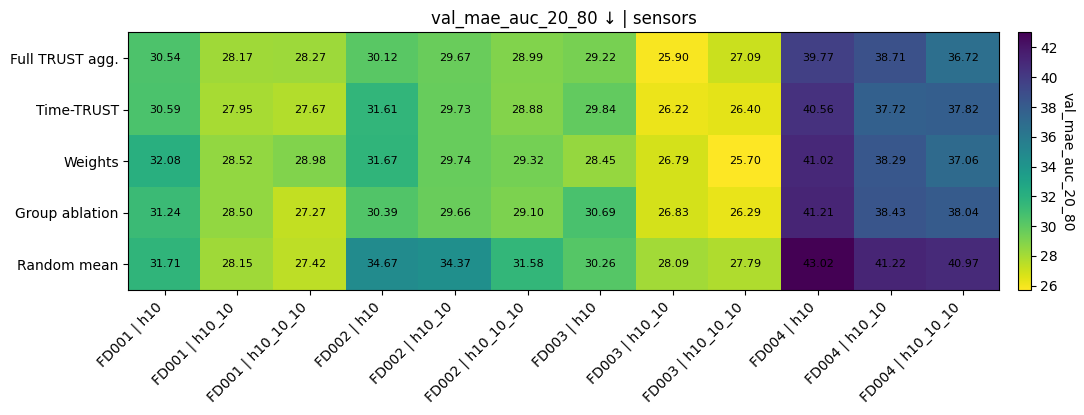

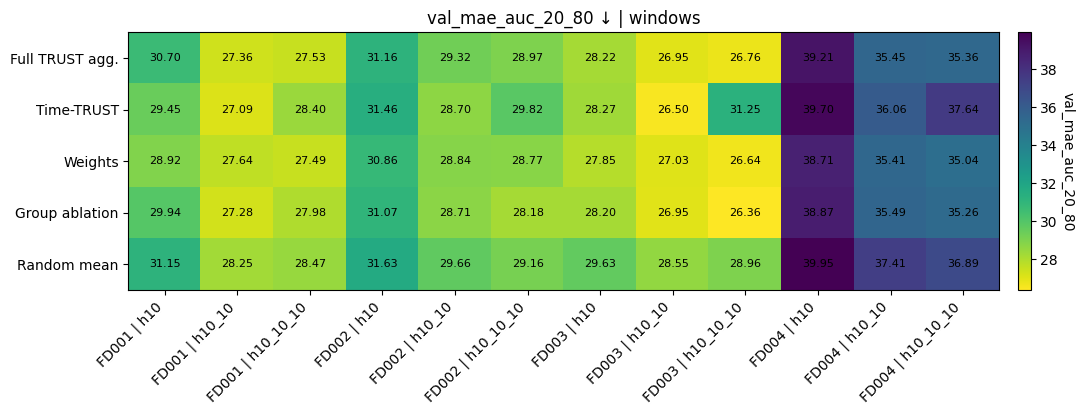

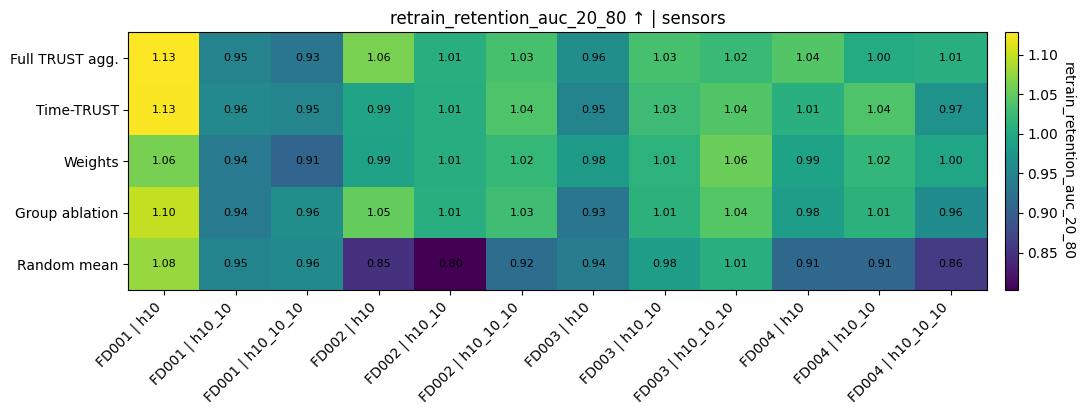

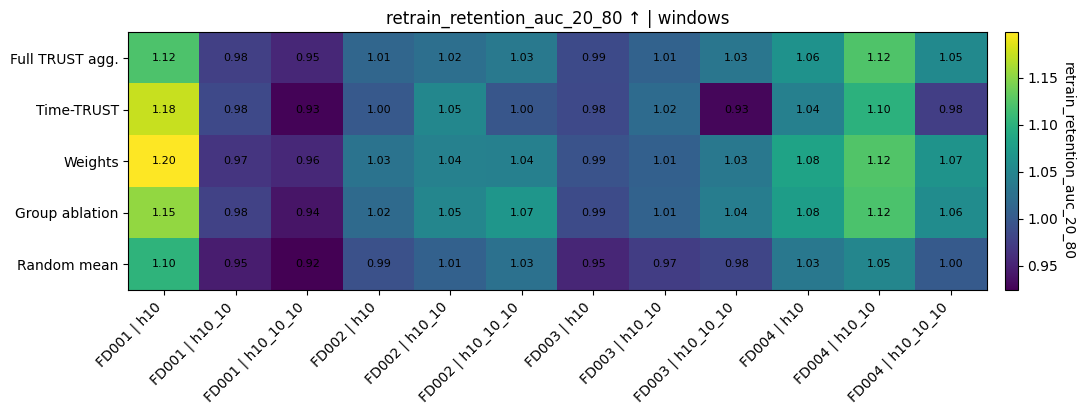

In [11]:
def _config_label(df):
    return df["dataset"].astype(str) + " | " + df["hidden_tag"].astype(str)

def plot_method_config_heatmap(
    data,
    metric,
    group_mode="sensors",
    *,
    cmap="viridis",
    vmin=None,
    vmax=None,
    lower_is_better=True,
):
    sub = data[data["group_mode"].astype(str).eq(group_mode)].copy()
    if sub.empty:
        print("No data for", group_mode)
        return None

    sub["config"] = _config_label(sub)
    p = sub.pivot_table(index="method_label", columns="config", values=metric, aggfunc="mean", observed=True)

    row_order = ["Full TRUST agg.", "Time-TRUST", "Weights", "Group ablation", "Random mean"]
    p = p.reindex([r for r in row_order if r in p.index])

    cols = []
    for ds in DATASET_ORDER:
        for h in HIDDEN_ORDER:
            c = f"{ds} | {h}"
            if c in p.columns:
                cols.append(c)
    p = p[cols]

    arr = p.to_numpy(dtype=float)
    fig_w = max(8, 0.75 * p.shape[1] + 2)
    fig_h = max(3.2, 0.55 * p.shape[0] + 1.5)
    fig, ax = plt.subplots(figsize=(fig_w, fig_h))

    im = ax.imshow(arr, aspect="auto", interpolation="nearest", cmap=cmap, vmin=vmin, vmax=vmax)
    ax.set_xticks(np.arange(p.shape[1]))
    ax.set_xticklabels(p.columns.tolist(), rotation=45, ha="right")
    ax.set_yticks(np.arange(p.shape[0]))
    ax.set_yticklabels(p.index.tolist())
    direction = "↓" if lower_is_better else "↑"
    ax.set_title(f"{metric} {direction} | {group_mode}")

    for i in range(p.shape[0]):
        for j in range(p.shape[1]):
            val = arr[i, j]
            ax.text(j, i, "NA" if not np.isfinite(val) else f"{val:.2f}", ha="center", va="center", fontsize=8)

    cbar = fig.colorbar(im, ax=ax, fraction=0.03, pad=0.02)
    cbar.ax.set_ylabel(metric, rotation=270, labelpad=12)
    fig.tight_layout()
    plt.show()
    return fig

if METRIC_MAE_20_80:
    _ = plot_method_config_heatmap(auc_compact, metric=METRIC_MAE_20_80, group_mode="sensors", cmap="viridis_r", lower_is_better=True)
    _ = plot_method_config_heatmap(auc_compact, metric=METRIC_MAE_20_80, group_mode="windows", cmap="viridis_r", lower_is_better=True)

if METRIC_RET_20_80:
    _ = plot_method_config_heatmap(auc_compact, metric=METRIC_RET_20_80, group_mode="sensors", cmap="viridis", lower_is_better=False)
    _ = plot_method_config_heatmap(auc_compact, metric=METRIC_RET_20_80, group_mode="windows", cmap="viridis", lower_is_better=False)

## Figura vertical estilo IEEE: una fila por subset y columnas sensor/window

Útil para inspección y para posible figura suplementaria.

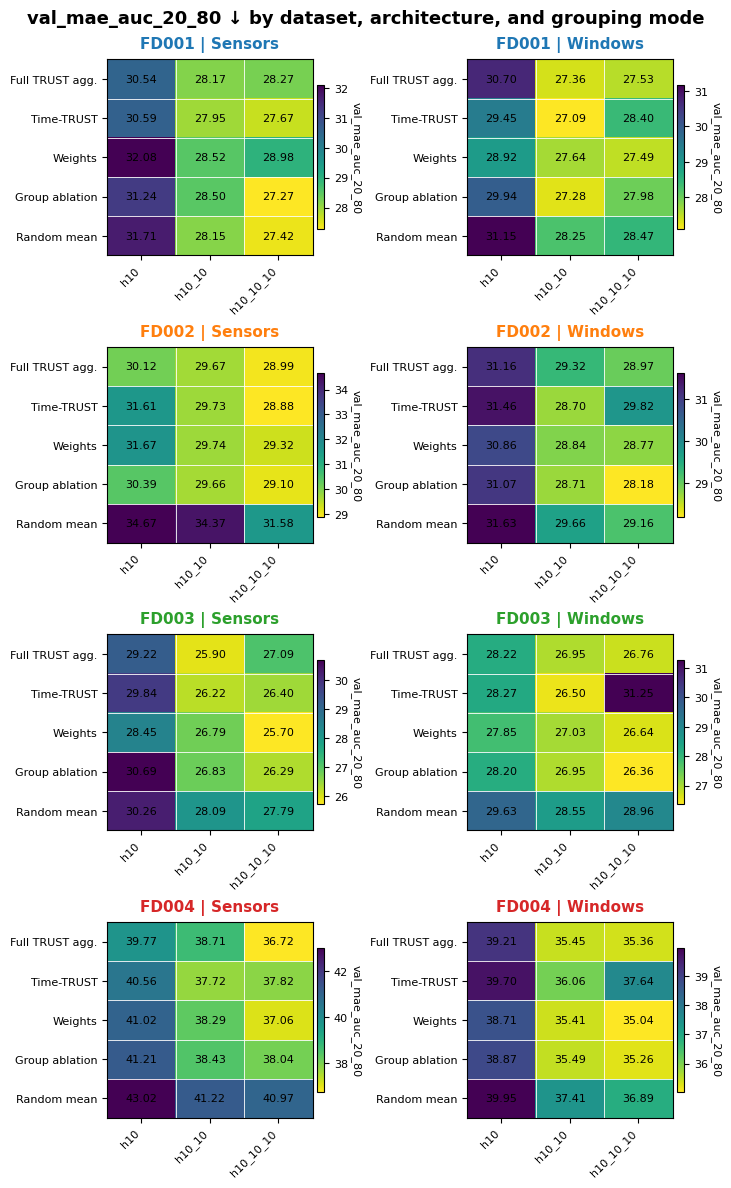

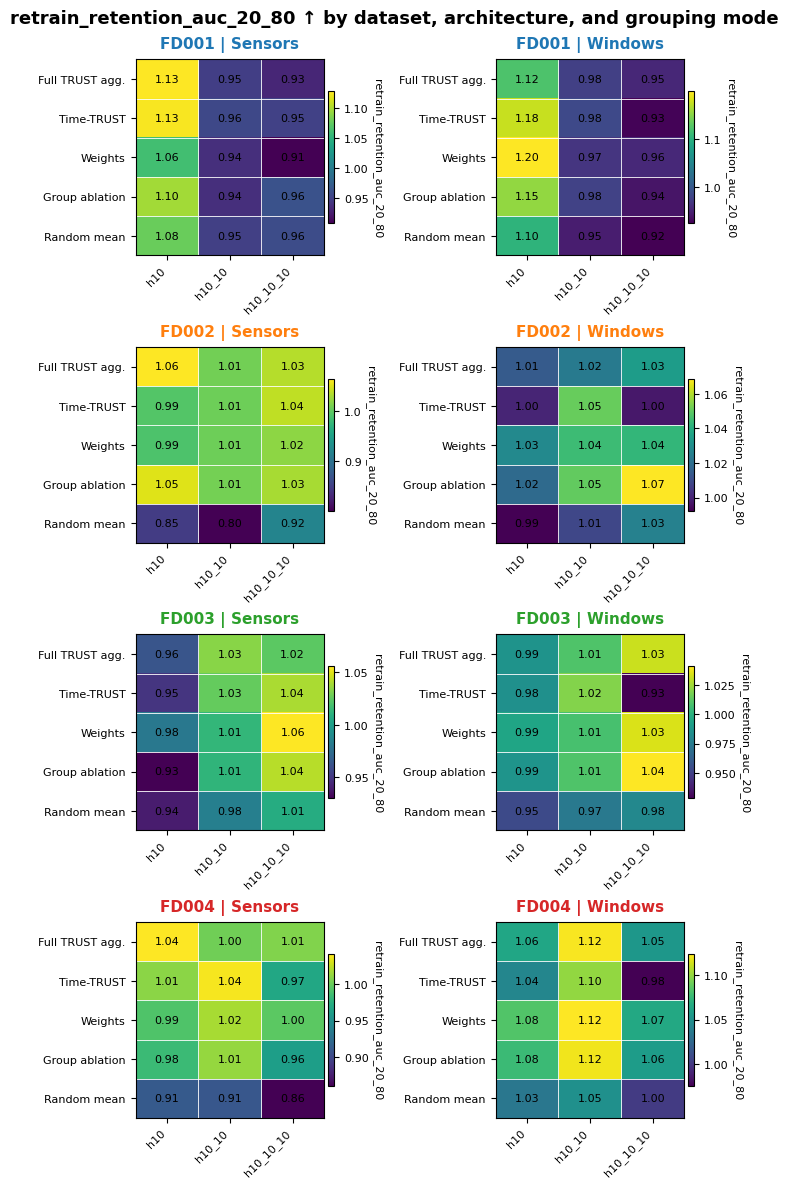

In [12]:
DATASET_COLORS = {
    "FD001": "#1f77b4",
    "FD002": "#ff7f0e",
    "FD003": "#2ca02c",
    "FD004": "#d62728",
}

GROUP_MODE_TITLES = {
    "sensors": "Sensors",
    "windows": "Windows",
}

def _build_panel_pivot(data, dataset, group_mode, metric):
    sub = data[
        data["dataset"].astype(str).eq(dataset)
        & data["group_mode"].astype(str).eq(group_mode)
    ].copy()

    p = sub.pivot_table(
        index="method_label",
        columns="hidden_tag",
        values=metric,
        aggfunc="mean",
        observed=True,
    )
    p = p.reindex(index=METHOD_LABEL_ORDER, columns=HIDDEN_ORDER)
    return p

def plot_ieee_vertical_retrain_heatmaps(
    data,
    metric,
    *,
    cmap="viridis",
    vmin=None,
    vmax=None,
    lower_is_better=True,
    figsize=(7.2, 11.5),
    annotate=True,
):
    fig, axes = plt.subplots(
        nrows=len(DATASET_ORDER),
        ncols=2,
        figsize=figsize,
        constrained_layout=True,
    )
    axes = np.atleast_2d(axes)

    for i, dataset in enumerate(DATASET_ORDER):
        for j, group_mode in enumerate(["sensors", "windows"]):
            ax = axes[i, j]
            p = _build_panel_pivot(data, dataset, group_mode, metric)
            arr = p.to_numpy(dtype=float)

            im = ax.imshow(
                arr,
                aspect="auto",
                interpolation="nearest",
                cmap=cmap,
                vmin=vmin,
                vmax=vmax,
            )

            ax.set_xticks(np.arange(len(HIDDEN_ORDER)))
            ax.set_xticklabels(HIDDEN_ORDER, rotation=45, ha="right", fontsize=8)

            ax.set_yticks(np.arange(len(METHOD_LABEL_ORDER)))
            ax.set_yticklabels(METHOD_LABEL_ORDER, fontsize=8)

            ax.set_title(
                f"{dataset} | {GROUP_MODE_TITLES[group_mode]}",
                fontsize=11,
                color=DATASET_COLORS.get(dataset, "black"),
                fontweight="bold",
                pad=8,
            )

            if annotate:
                for r in range(arr.shape[0]):
                    for c in range(arr.shape[1]):
                        val = arr[r, c]
                        txt = "NA" if not np.isfinite(val) else f"{val:.2f}"
                        ax.text(c, r, txt, ha="center", va="center", fontsize=8, color="black")

            cbar = fig.colorbar(im, ax=ax, fraction=0.035, pad=0.02)
            cbar.ax.set_ylabel(metric, rotation=270, labelpad=10, fontsize=8)
            cbar.ax.tick_params(labelsize=8)

            ax.set_xticks(np.arange(-0.5, len(HIDDEN_ORDER), 1), minor=True)
            ax.set_yticks(np.arange(-0.5, len(METHOD_LABEL_ORDER), 1), minor=True)
            ax.grid(which="minor", color="white", linestyle="-", linewidth=0.6)
            ax.tick_params(which="minor", bottom=False, left=False)

    direction = "↓" if lower_is_better else "↑"
    fig.suptitle(f"{metric} {direction} by dataset, architecture, and grouping mode", fontsize=13, fontweight="bold", y=1.02)
    plt.show()
    return fig

if METRIC_MAE_20_80:
    _ = plot_ieee_vertical_retrain_heatmaps(
        auc_compact,
        metric=METRIC_MAE_20_80,
        cmap="viridis_r",
        lower_is_better=True,
        figsize=(7.2, 11.5),
    )

if METRIC_RET_20_80:
    _ = plot_ieee_vertical_retrain_heatmaps(
        auc_compact,
        metric=METRIC_RET_20_80,
        cmap="viridis",
        lower_is_better=False,
        figsize=(7.2, 11.5),
    )

In [13]:
METRIC_DISPLAY_NAMES = {
    "val_mae_auc": "Validation MAE AUC",
    "val_mae_auc_20_80": "Validation MAE AUC (20–80%)",
    "retrain_retention_auc": "Retrained Retention AUC",
    "retrain_retention_auc_20_80": "Retrained Retention AUC (20–80%)",
    "val_rmse_auc": "Validation RMSE AUC",
    "val_rmse_auc_20_80": "Validation RMSE AUC (20–80%)",
}


def metric_display_name(metric: str) -> str:
    return METRIC_DISPLAY_NAMES.get(metric, metric)


def plot_ieee_vertical_retrain_heatmaps(
    data,
    metric,
    *,
    cmap="viridis",
    vmin=None,
    vmax=None,
    lower_is_better=True,
    figsize=(7.2, 11.5),
    annotate=True,
    title=None,
):
    metric_name = metric_display_name(metric)

    fig, axes = plt.subplots(
        nrows=len(DATASET_ORDER),
        ncols=2,
        figsize=figsize,
        constrained_layout=True,
    )
    axes = np.atleast_2d(axes)

    for i, dataset in enumerate(DATASET_ORDER):
        for j, group_mode in enumerate(["sensors", "windows"]):
            ax = axes[i, j]
            p = _build_panel_pivot(data, dataset, group_mode, metric)
            arr = p.to_numpy(dtype=float)

            im = ax.imshow(
                arr,
                aspect="auto",
                interpolation="nearest",
                cmap=cmap,
                vmin=vmin,
                vmax=vmax,
            )

            ax.set_xticks(np.arange(len(HIDDEN_ORDER)))
            ax.set_xticklabels(HIDDEN_ORDER, rotation=45, ha="right", fontsize=8)

            ax.set_yticks(np.arange(len(METHOD_LABEL_ORDER)))
            ax.set_yticklabels(METHOD_LABEL_ORDER, fontsize=8)

            ax.set_title(
                f"{dataset} | {GROUP_MODE_TITLES[group_mode]}",
                fontsize=11,
                color=DATASET_COLORS.get(dataset, "black"),
                fontweight="bold",
                pad=8,
            )

            if annotate:
                for r in range(arr.shape[0]):
                    for c in range(arr.shape[1]):
                        val = arr[r, c]
                        txt = "NA" if not np.isfinite(val) else f"{val:.2f}"
                        ax.text(
                            c,
                            r,
                            txt,
                            ha="center",
                            va="center",
                            fontsize=8,
                            color="black",
                        )

            cbar = fig.colorbar(im, ax=ax, fraction=0.035, pad=0.02)
            cbar.ax.set_ylabel(metric_name, rotation=270, labelpad=10, fontsize=8)
            cbar.ax.tick_params(labelsize=8)

            ax.set_xticks(np.arange(-0.5, len(HIDDEN_ORDER), 1), minor=True)
            ax.set_yticks(np.arange(-0.5, len(METHOD_LABEL_ORDER), 1), minor=True)
            ax.grid(which="minor", color="white", linestyle="-", linewidth=0.6)
            ax.tick_params(which="minor", bottom=False, left=False)

    direction = "↓" if lower_is_better else "↑"

    if title is None:
        title = f"{metric_name} {direction} by dataset, architecture, and grouping mode"

    fig.suptitle(
        title,
        fontsize=13,
        fontweight="bold",
        y=1.02,
    )

    plt.show()
    return fig

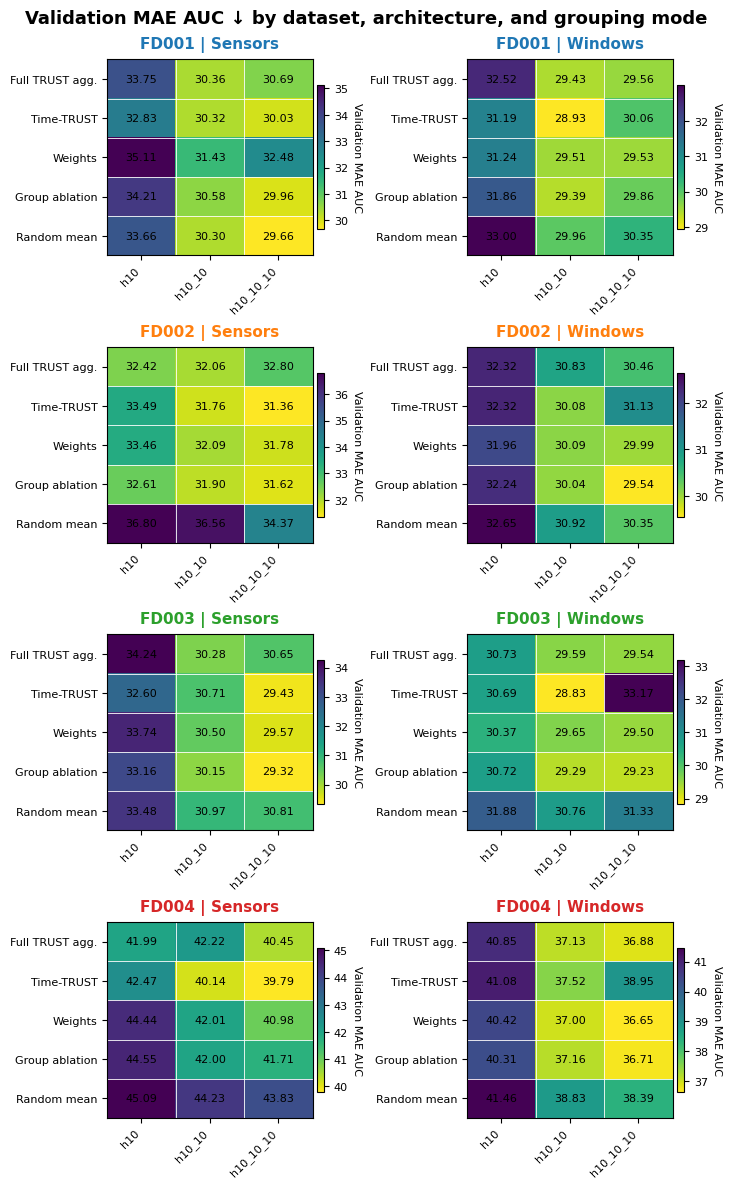

In [14]:
fig = plot_ieee_vertical_retrain_heatmaps(
    auc_compact,
    metric="val_mae_auc",
    cmap="viridis_r",
    lower_is_better=True,
    figsize=(7.2, 11.5),
    title="Validation MAE AUC ↓ by dataset, architecture, and grouping mode",
)

fig.savefig(
    "figures/retrain_val_mae_auc_total_heatmap.png",
    dpi=300,
    bbox_inches="tight",
)

In [15]:
def plot_ieee_vertical_retrain_heatmaps(
    data,
    metric,
    *,
    cmap="viridis",
    vmin=None,
    vmax=None,
    lower_is_better=True,
    figsize=(7.2, 11.5),
    annotate=True,
    title=None,
    shared_colorbar="by_dataset",  # "by_dataset" or "global"
):
    metric_name = metric_display_name(metric)

    fig, axes = plt.subplots(
        nrows=len(DATASET_ORDER),
        ncols=2,
        figsize=figsize,
        constrained_layout=True,
    )
    axes = np.atleast_2d(axes)

    # Guardamos una imagen por fila/dataset.
    ims_by_dataset = {}

    for i, dataset in enumerate(DATASET_ORDER):
        ims_by_dataset[dataset] = None

        for j, group_mode in enumerate(["sensors", "windows"]):
            ax = axes[i, j]
            p = _build_panel_pivot(data, dataset, group_mode, metric)
            arr = p.to_numpy(dtype=float)

            # Si no pasas vmin/vmax, calcula escala compartida por dataset/fila.
            row_vmin, row_vmax = vmin, vmax
            if shared_colorbar == "by_dataset" and (vmin is None or vmax is None):
                row_vals = []
                for gm in ["sensors", "windows"]:
                    p_row = _build_panel_pivot(data, dataset, gm, metric)
                    vals = p_row.to_numpy(dtype=float).ravel()
                    vals = vals[np.isfinite(vals)]
                    if len(vals):
                        row_vals.append(vals)

                if row_vals:
                    row_vals = np.concatenate(row_vals)
                    if vmin is None:
                        row_vmin = float(np.nanmin(row_vals))
                    if vmax is None:
                        row_vmax = float(np.nanmax(row_vals))

            im = ax.imshow(
                arr,
                aspect="auto",
                interpolation="nearest",
                cmap=cmap,
                vmin=row_vmin,
                vmax=row_vmax,
            )

            # Cualquier im de la fila sirve para el colorbar compartido,
            # porque ambos subplots de la fila usan la misma escala.
            ims_by_dataset[dataset] = im

            ax.set_xticks(np.arange(len(HIDDEN_ORDER)))
            ax.set_xticklabels(HIDDEN_ORDER, rotation=45, ha="right", fontsize=8)

            ax.set_yticks(np.arange(len(METHOD_LABEL_ORDER)))
            ax.set_yticklabels(METHOD_LABEL_ORDER, fontsize=8)

            ax.set_title(
                f"{dataset} | {GROUP_MODE_TITLES[group_mode]}",
                fontsize=11,
                color=DATASET_COLORS.get(dataset, "black"),
                fontweight="bold",
                pad=8,
            )

            if annotate:
                for r in range(arr.shape[0]):
                    for c in range(arr.shape[1]):
                        val = arr[r, c]
                        txt = "NA" if not np.isfinite(val) else f"{val:.2f}"
                        ax.text(
                            c,
                            r,
                            txt,
                            ha="center",
                            va="center",
                            fontsize=8,
                            color="black",
                        )

            ax.set_xticks(np.arange(-0.5, len(HIDDEN_ORDER), 1), minor=True)
            ax.set_yticks(np.arange(-0.5, len(METHOD_LABEL_ORDER), 1), minor=True)
            ax.grid(which="minor", color="white", linestyle="-", linewidth=0.6)
            ax.tick_params(which="minor", bottom=False, left=False)

    # Colorbar compartido por fila/dataset.
    if shared_colorbar == "by_dataset":
        for i, dataset in enumerate(DATASET_ORDER):
            im = ims_by_dataset.get(dataset)
            if im is None:
                continue

            cbar = fig.colorbar(
                im,
                ax=axes[i, :],
                fraction=0.035,
                pad=0.02,
            )
            cbar.ax.set_ylabel(
                f"{metric_name} | {dataset}",
                rotation=270,
                labelpad=12,
                fontsize=8,
            )
            cbar.ax.tick_params(labelsize=8)

    elif shared_colorbar == "global":
        im_global = None
        for dataset in reversed(DATASET_ORDER):
            if ims_by_dataset.get(dataset) is not None:
                im_global = ims_by_dataset[dataset]
                break

        if im_global is not None:
            cbar = fig.colorbar(
                im_global,
                ax=axes,
                fraction=0.025,
                pad=0.02,
            )
            cbar.ax.set_ylabel(metric_name, rotation=270, labelpad=12, fontsize=8)
            cbar.ax.tick_params(labelsize=8)

    else:
        raise ValueError("shared_colorbar must be 'by_dataset' or 'global'")

    direction = "↓" if lower_is_better else "↑"

    if title is None:
        title = f"{metric_name} {direction} by dataset, architecture, and grouping mode"

    fig.suptitle(
        title,
        fontsize=13,
        fontweight="bold",
        y=1.02,
    )

    plt.show()
    return fig

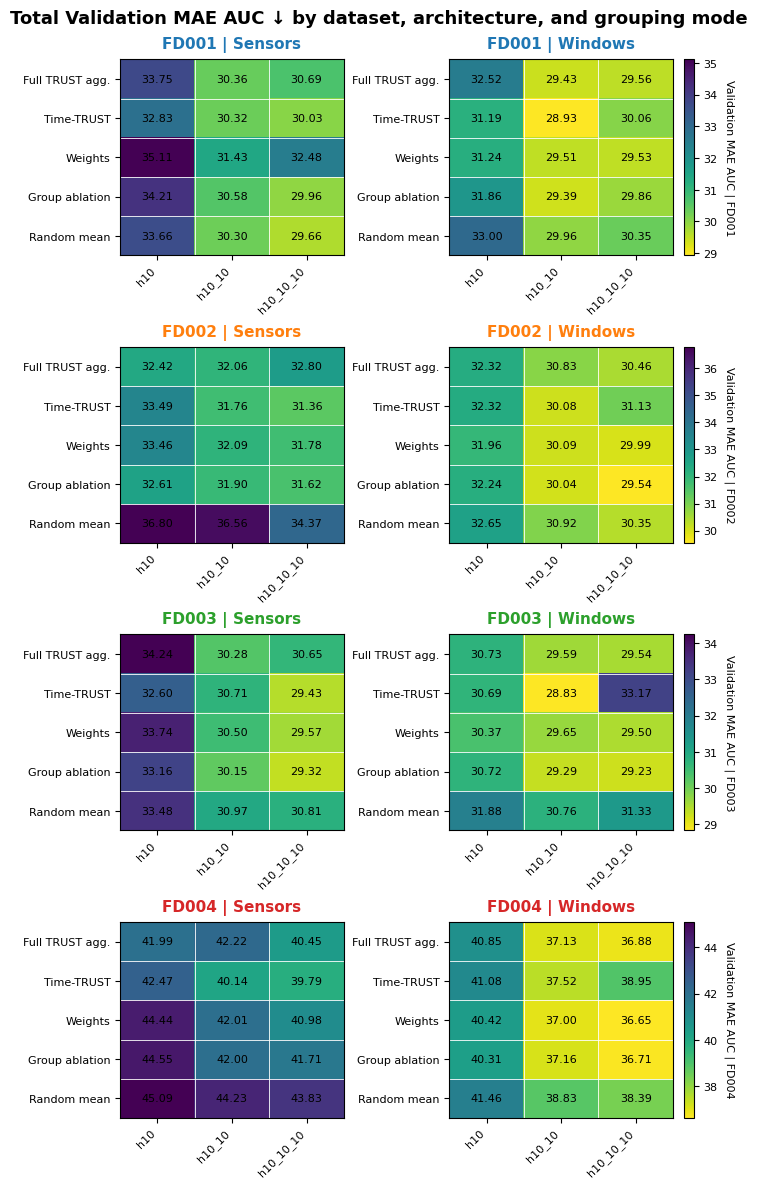

In [16]:
_ = plot_ieee_vertical_retrain_heatmaps(
    auc_compact,
    metric="val_mae_auc",
    cmap="viridis_r",
    lower_is_better=True,
    figsize=(7.2, 11.5),
    title="Total Validation MAE AUC ↓ by dataset, architecture, and grouping mode",
    shared_colorbar="by_dataset",
)

## Curvas promedio

Promedia curvas por modo y método. Para random, primero promedia por configuración/trial y luego muestra media global.

curve_x: fraction_kept
curve_mae: val_mae
curve_ret: retrain_retention


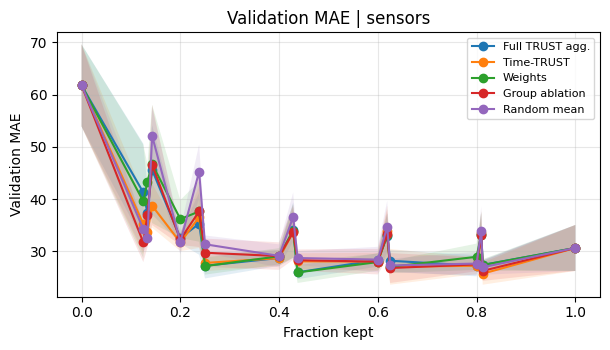

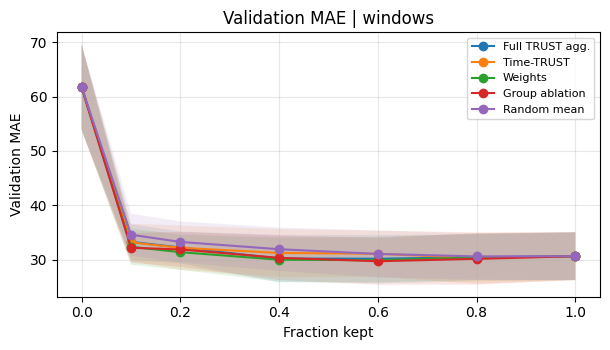

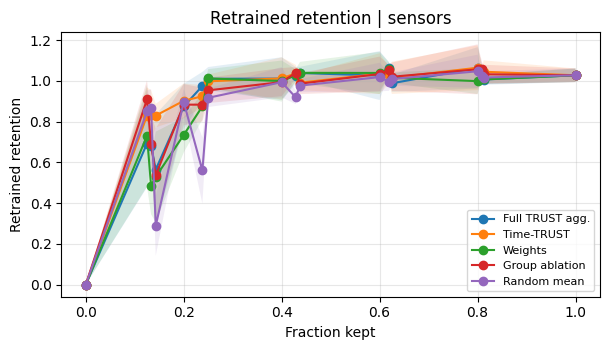

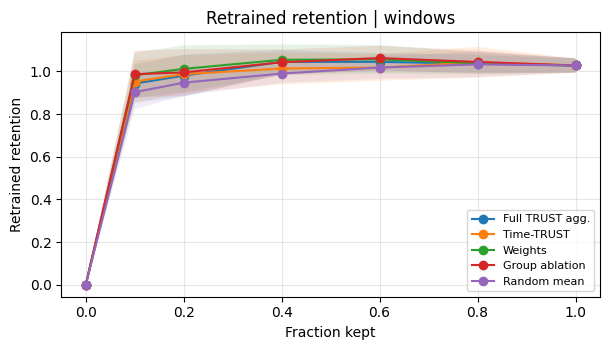

In [12]:
# Detect common curve columns.
curve_x = "fraction_kept" if "fraction_kept" in curves.columns else None
curve_mae = "val_mae" if "val_mae" in curves.columns else ("mae" if "mae" in curves.columns else None)
curve_ret = "retrain_retention" if "retrain_retention" in curves.columns else ("retention" if "retention" in curves.columns else None)

print("curve_x:", curve_x)
print("curve_mae:", curve_mae)
print("curve_ret:", curve_ret)

def compact_curves_for_plot(curves_df, y_col):
    if y_col is None or curve_x is None:
        return pd.DataFrame()

    det = curves_df[curves_df["method"].astype(str).ne("random_permutation")].copy()
    rnd = curves_df[curves_df["method"].astype(str).eq("random_permutation")].copy()

    parts = [det]
    if not rnd.empty:
        rnd_mean = (
            rnd
            .groupby(id_cols + [curve_x], as_index=False, observed=True)
            .agg(**{y_col: (y_col, "mean")})
        )
        rnd_mean["method"] = "random_mean"
        rnd_mean["method_label"] = "Random mean"
        rnd_mean["random_trial"] = -999
        parts.append(rnd_mean)

    out = pd.concat(parts, ignore_index=True, sort=False)
    out["method_label"] = out["method"].map(lambda m: METHOD_LABELS.get(str(m), str(m)))
    return out

def plot_mean_curves(curves_df, y_col, *, group_mode="sensors", ylabel=None, lower_is_better=True):
    d = compact_curves_for_plot(curves_df, y_col)
    d = d[d["group_mode"].astype(str).eq(group_mode)].copy()
    if d.empty:
        print("No curves for", group_mode, y_col)
        return None

    summary = (
        d.groupby(["method_label", curve_x], as_index=False, observed=True)
        .agg(mean=(y_col, "mean"), std=(y_col, "std"))
    )

    fig, ax = plt.subplots(figsize=(6.2, 3.6))
    for label in METHOD_LABEL_ORDER:
        sub = summary[summary["method_label"].astype(str).eq(label)].sort_values(curve_x)
        if sub.empty:
            continue
        ax.plot(sub[curve_x], sub["mean"], marker="o", label=label)
        ax.fill_between(sub[curve_x], sub["mean"] - sub["std"], sub["mean"] + sub["std"], alpha=0.12)

    ax.set_title(f"{ylabel or y_col} | {group_mode}")
    ax.set_xlabel("Fraction kept")
    ax.set_ylabel(ylabel or y_col)
    ax.grid(True, alpha=0.3)
    ax.legend(fontsize=8)
    fig.tight_layout()
    plt.show()
    return fig

if curve_mae:
    _ = plot_mean_curves(curves, curve_mae, group_mode="sensors", ylabel="Validation MAE", lower_is_better=True)
    _ = plot_mean_curves(curves, curve_mae, group_mode="windows", ylabel="Validation MAE", lower_is_better=True)

if curve_ret:
    _ = plot_mean_curves(curves, curve_ret, group_mode="sensors", ylabel="Retrained retention", lower_is_better=False)
    _ = plot_mean_curves(curves, curve_ret, group_mode="windows", ylabel="Retrained retention", lower_is_better=False)

## Curva por configuración específica

Cambia `CFG` para inspeccionar casos concretos, por ejemplo el outlier FD003/h10_10_10/windows.

,dataset,window_tag,hidden_tag,group_mode,method,random_trial,k,n_groups,fraction_kept,n_features_kept,input_dim,train_mae,train_rmse,val_mae,val_rmse,retrain_retention,mae_full_ref,rmse_full_ref,mae_mean_ref,rmse_mean_ref,mean_y_train,ranking_file,train_seed,cache_hit,epochs,last_train_loss,last_val_loss,method_label
833,FD003,W30_step1,h10_10_10,windows,fulltrust_agg_selection,-1,0,30,0.0,0,0,NaN,NaN,71.782883,90.744240,0.000000,28.130693,44.138401,71.782883,90.74424,125.619827,mlp_baselines/FD003/W30_step1/h10_10_10/rankin...,-1,False,NaN,NaN,NaN,Full TRUST agg.
834,FD003,W30_step1,h10_10_10,windows,fulltrust_agg_selection,-1,3,30,0.1,48,48,35.745987,52.337070,29.989592,43.203201,0.957416,28.130693,44.138401,71.782883,90.74424,125.619827,mlp_baselines/FD003/W30_step1/h10_10_10/rankin...,2172855579,False,60.0,2751.313721,1866.516602,Full TRUST agg.
835,FD003,W30_step1,h10_10_10,windows,fulltrust_agg_selection,-1,6,30,0.2,96,96,32.198330,47.433002,30.080219,44.646851,0.955340,28.130693,44.138401,71.782883,90.74424,125.619827,mlp_baselines/FD003/W30_step1/h10_10_10/rankin...,2958425103,False,60.0,2265.548828,1993.341309,Full TRUST agg.
836,FD003,W30_step1,h10_10_10,windows,fulltrust_agg_selection,-1,12,30,0.4,192,192,28.170649,43.339104,25.695736,39.695946,1.055781,28.130693,44.138401,71.782883,90.74424,125.619827,mlp_baselines/FD003/W30_step1/h10_10_10/rankin...,3545693762,False,60.0,1898.946411,1575.767944,Full TRUST agg.
837,FD003,W30_step1,h10_10_10,windows,fulltrust_agg_selection,-1,18,30,0.6,288,288,27.126179,41.033585,26.453173,39.814129,1.038429,28.130693,44.138401,71.782883,90.74424,125.619827,mlp_baselines/FD003/W30_step1/h10_10_10/rankin...,303588972,False,60.0,1707.629639,1585.164673,Full TRUST agg.


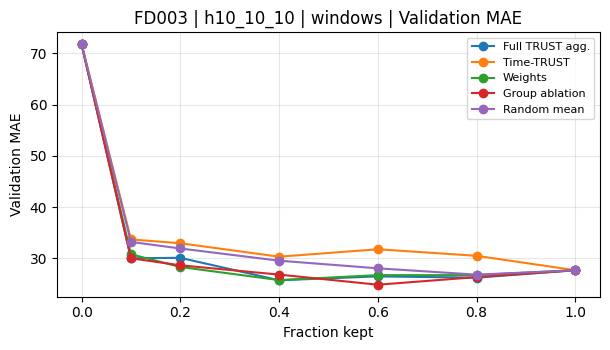

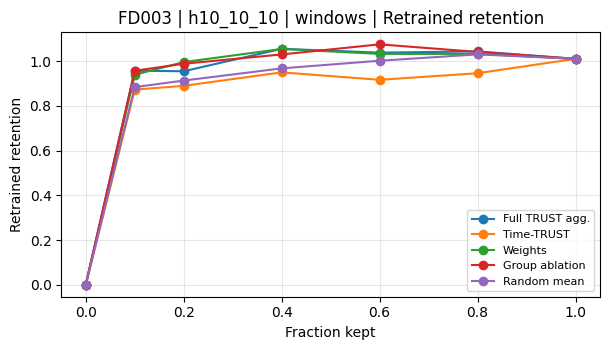

In [13]:
CFG = {
    "dataset": "FD003",
    "window_tag": "W30_step1",
    "hidden_tag": "h10_10_10",
    "group_mode": "windows",
}

def filter_cfg(df, cfg):
    m = np.ones(len(df), dtype=bool)
    for k, v in cfg.items():
        if k in df.columns:
            m &= df[k].astype(str).eq(str(v))
    return df[m].copy()

cfg_curves = filter_cfg(curves, CFG)
display(cfg_curves.head())

def plot_cfg_curves(cfg_curves, y_col, *, ylabel=None, lower_is_better=True):
    if y_col is None or curve_x is None:
        print("Missing curve column.")
        return None

    d = compact_curves_for_plot(cfg_curves, y_col)
    if d.empty:
        print("No data.")
        return None

    fig, ax = plt.subplots(figsize=(6.2, 3.6))
    for label in METHOD_LABEL_ORDER:
        sub = d[d["method_label"].astype(str).eq(label)].sort_values(curve_x)
        if sub.empty:
            continue
        ax.plot(sub[curve_x], sub[y_col], marker="o", label=label)

    title = " | ".join(str(CFG[k]) for k in ["dataset", "hidden_tag", "group_mode"] if k in CFG)
    ax.set_title(f"{title} | {ylabel or y_col}")
    ax.set_xlabel("Fraction kept")
    ax.set_ylabel(ylabel or y_col)
    ax.grid(True, alpha=0.3)
    ax.legend(fontsize=8)
    fig.tight_layout()
    plt.show()
    return fig

if curve_mae:
    _ = plot_cfg_curves(cfg_curves, curve_mae, ylabel="Validation MAE", lower_is_better=True)
if curve_ret:
    _ = plot_cfg_curves(cfg_curves, curve_ret, ylabel="Retrained retention", lower_is_better=False)

## Time-TRUST vs Full TRUST agregado

Diferencias pareadas por configuración.

Para MAE: negativo significa que Time-TRUST tiene menor MAE AUC que Full TRUST agregado.
Para retention: positivo significa que Time-TRUST tiene mayor retention AUC que Full TRUST agregado.

In [14]:
def paired_delta(method_a, method_b, metric):
    a = auc_compact[auc_compact["method"].astype(str).eq(method_a)][id_cols + [metric]].rename(columns={metric: "metric_a"})
    b = auc_compact[auc_compact["method"].astype(str).eq(method_b)][id_cols + [metric]].rename(columns={metric: "metric_b"})
    d = a.merge(b, on=id_cols, how="inner")
    d["delta_a_minus_b"] = d["metric_a"] - d["metric_b"]
    return d

if METRIC_MAE_20_80:
    tt_vs_ft_mae = paired_delta("timetrust_selection", "fulltrust_agg_selection", METRIC_MAE_20_80)
    print("Time-TRUST - Full TRUST agg. for", METRIC_MAE_20_80, "(negative is better for Time-TRUST)")
    display(
        tt_vs_ft_mae
        .groupby("group_mode", observed=True)
        .agg(
            n=("delta_a_minus_b", "count"),
            median_delta=("delta_a_minus_b", "median"),
            mean_delta=("delta_a_minus_b", "mean"),
            iqr_delta=("delta_a_minus_b", iqr),
            win_rate=("delta_a_minus_b", lambda x: float(np.mean(np.asarray(x) < 0))),
        )
        .round(4)
    )

if METRIC_RET_20_80:
    tt_vs_ft_ret = paired_delta("timetrust_selection", "fulltrust_agg_selection", METRIC_RET_20_80)
    print("Time-TRUST - Full TRUST agg. for", METRIC_RET_20_80, "(positive is better for Time-TRUST)")
    display(
        tt_vs_ft_ret
        .groupby("group_mode", observed=True)
        .agg(
            n=("delta_a_minus_b", "count"),
            median_delta=("delta_a_minus_b", "median"),
            mean_delta=("delta_a_minus_b", "mean"),
            iqr_delta=("delta_a_minus_b", iqr),
            win_rate=("delta_a_minus_b", lambda x: float(np.mean(np.asarray(x) > 0))),
        )
        .round(4)
    )

Time-TRUST - Full TRUST agg. for val_mae_auc_20_80 (negative is better for Time-TRUST)


,n,median_delta,mean_delta,iqr_delta,win_rate
group_mode,,,,,
sensors,12,0.0521,0.1529,0.9699,0.4167
windows,12,0.3971,0.6145,1.1671,0.3333


Time-TRUST - Full TRUST agg. for retrain_retention_auc_20_80 (positive is better for Time-TRUST)


,n,median_delta,mean_delta,iqr_delta,win_rate
group_mode,,,,,
sensors,12,-0.0023,-0.0068,0.0276,0.4167
windows,12,-0.0169,-0.0170,0.0399,0.3333


## Exportar tablas compactas

Estas tablas son útiles para trasladar resultados al manuscrito.

In [ ]:
EXPORT_DIR = TABLES_DIR / "retrain_analysis_exports"
EXPORT_DIR.mkdir(parents=True, exist_ok=True)

auc_compact.to_csv(EXPORT_DIR / "retrain_auc_compact_with_random_mean.csv", index=False)
method_summary.to_csv(EXPORT_DIR / "retrain_method_summary_mean_std.csv", index=False)

if robust_mae is not None:
    robust_mae.to_csv(EXPORT_DIR / "retrain_robust_summary_val_mae_auc_20_80.csv", index=False)
if robust_ret is not None:
    robust_ret.to_csv(EXPORT_DIR / "retrain_robust_summary_retention_auc_20_80.csv", index=False)

print("Saved exports to:", EXPORT_DIR)
for p in sorted(EXPORT_DIR.glob("*.csv")):
    print(" -", p)